# Section A : Given fault path and implementing gates, output the two logical errors and the syndromes

In [1]:
import numpy as np
from itertools import product

# ---------------------------------------------------------------------------
# Pauli algebra — binary symplectic representation
# ---------------------------------------------------------------------------
# Single-qubit Pauli: (x, z) in F_2^2
#   (0,0)=I  (1,0)=X  (1,1)=Y  (0,1)=Z
# Multiplication (mod phase): XOR componentwise

PAULI_LABEL   = {(0,0):'I', (1,0):'X', (1,1):'Y', (0,1):'Z'}
PAULI_FROM_CH = {'I':(0,0), 'X':(1,0), 'Y':(1,1), 'Z':(0,1)}
LOGICAL_NAMES = ['I', 'X', 'Y', 'Z']

def pauli_mul(xv1, zv1, xv2, zv2):
    return xv1 ^ xv2, zv1 ^ zv2

def pauli_anticommutes(xv1, zv1, xv2, zv2):
    return bool((np.dot(xv1, zv2) + np.dot(zv1, xv2)) % 2)

def pauli_weight(xv, zv):
    return int(np.sum(xv | zv))

def pauli_str(xv, zv):
    return ''.join(PAULI_LABEL[(int(xv[i]), int(zv[i]))] for i in range(len(xv)))

def str_to_pauli(s):
    s = s.upper()
    assert len(s) == 5, "Need exactly 5 characters"
    xv = np.array([PAULI_FROM_CH[c][0] for c in s], dtype=int)
    zv = np.array([PAULI_FROM_CH[c][1] for c in s], dtype=int)
    return xv, zv

def all_paulis(n):
    out = []
    for bits in product([0,1], repeat=2*n):
        xv = np.array(bits[0::2], dtype=int)
        zv = np.array(bits[1::2], dtype=int)
        out.append((xv, zv))
    return out

# ---------------------------------------------------------------------------
# [[5,1,3]] stabilizer code
# ---------------------------------------------------------------------------
N = 5

STAB_GENS = [
    (np.array([1,0,0,1,0]), np.array([0,1,1,0,0])),  # g1: XZZXI
    (np.array([0,1,0,0,1]), np.array([0,0,1,1,0])),  # g2: IXZZX
    (np.array([1,0,1,0,0]), np.array([0,0,0,1,1])),  # g3: XIXZZ
    (np.array([0,1,0,1,0]), np.array([1,0,0,0,1])),  # g4: ZXIXZ
]
XLOG = (np.array([1,1,1,1,1]), np.array([0,0,0,0,0]))  # X_L = XXXXX
ZLOG = (np.array([0,0,0,0,0]), np.array([1,1,1,1,1]))  # Z_L = ZZZZZ

def compute_syndrome(xv, zv):
    s = 0
    for i, (gx, gz) in enumerate(STAB_GENS):
        bit = (np.dot(xv, gz) + np.dot(zv, gx)) % 2
        s |= (int(bit) << (3 - i))
    return s

def syndrome_bits(s):
    return [(s >> (3-i)) & 1 for i in range(4)]

def build_corrections():
    best = {}
    for xv, zv in all_paulis(N):
        s = compute_syndrome(xv, zv)
        w = pauli_weight(xv, zv)
        if s not in best or w < best[s][0]:
            best[s] = (w, xv.copy(), zv.copy())
    return {s: (xv, zv) for s, (w, xv, zv) in best.items()}

CORRECTIONS = build_corrections()

def logical_class(xv, zv):
    """Returns (idx, (x_log, z_log))  idx: 0=I 1=X 2=Y 3=Z"""
    x_log = int(pauli_anticommutes(xv, zv, *ZLOG))
    z_log = int(pauli_anticommutes(xv, zv, *XLOG))
    idx = {(0,0):0, (1,0):1, (1,1):2, (0,1):3}[(x_log, z_log)]
    return idx, (x_log, z_log)

def logical_mul(l1_bits, l2_bits):
    """Multiply two logical Paulis given as (x_log, z_log) tuples. Returns (idx, bits)."""
    bits = (l1_bits[0] ^ l2_bits[0], l1_bits[1] ^ l2_bits[1])
    idx  = {(0,0):0, (1,0):1, (1,1):2, (0,1):3}[bits]
    return idx, bits

print("[[5,1,3]] setup loaded.")
print("Stabilizer generators:", [pauli_str(gx, gz) for gx, gz in STAB_GENS])
print("X_L =", pauli_str(*XLOG), "   Z_L =", pauli_str(*ZLOG))

[[5,1,3]] setup loaded.
Stabilizer generators: ['XZZXI', 'IXZZX', 'XIXZZ', 'ZXIXZ']
X_L = XXXXX    Z_L = ZZZZZ


In [2]:
# ============================================================
#  >>> INPUTS: Set the fault path here <<<
# ============================================================
#
# Circuit layout (truncated exRec, back-to-front analysis):
#
#   P1 - FTEC_a - P2 - [Z gate] - P3 - * - FTEC_b - P4 - [X gate] - P5 - FTEC_c - P6
#
#   FTEC_a : leading EC of Z exRec  — corrects syndrome(P1)
#   *      : star decoder (between P3 and FTEC_b) — captures s_in for X exRec
#   FTEC_b : leading EC of X exRec  — corrects the syndrome injected by the star decoder
#   FTEC_c : trailing EC of X exRec
#
# Transversal Z = ZZZZZ and X = XXXXX act trivially on Pauli errors in the
# binary symplectic representation (they only introduce phases, which are ignored).
#
# Each Pi is a 5-character string with characters in {I, X, Y, Z}.

P1 = 'IIIII'   # fault before FTEC_a  (sets incoming syndrome of Z exRec)
P2 = 'IIIII'   # fault between FTEC_a and Z gate
P3 = 'IIIII'   # fault between Z gate and star decoder (*)
P4 = 'IXIII'   # fault between FTEC_b and X gate
P5 = 'IIIII'   # fault between X gate and FTEC_c
P6 = 'IIIII'   # fault after FTEC_c (output data error, not corrected)
# ============================================================

In [3]:
# ============================================================
#  Z exRec analysis
#  Structure: P1 - FTEC_a - P2 - [Z] - P3 - (star decoder boundary)
# ============================================================

xP1, zP1 = str_to_pauli(P1)
xP2, zP2 = str_to_pauli(P2)
xP3, zP3 = str_to_pauli(P3)

# --- Step 1: FTEC_a sees syndrome(P1) and applies recovery U_Z = Q_{syndrome(P1)}
s_P1   = compute_syndrome(xP1, zP1)
Ux, Uz = CORRECTIONS[s_P1]          # U_Z: the recovery that FTEC_a applies
U_Z_str = pauli_str(Ux, Uz)

# --- Step 2: After FTEC_a correction — P1 · U_Z has syndrome 0, possible logical residual
xAft, zAft = pauli_mul(xP1, zP1, Ux, Uz)   # P1 · U_Z  (syndrome 0)

# --- Step 3: P2 then Z gate (trivial in symplectic) then P3 accumulate
#     E_star = P1·U_Z · P2 · P3   (total error at the star decoder position)
xE_star, zE_star = pauli_mul(xAft, zAft, xP2, zP2)
xE_star, zE_star = pauli_mul(xE_star, zE_star, xP3, zP3)

# --- Step 4: Syndrome at star decoder → becomes s_in for X exRec
s_in_X = compute_syndrome(xE_star, zE_star)
# (Note: syndrome(P1·U_Z) = 0, so s_in_X = syndrome(P2·P3) only)

# --- Step 5: Virtual correction at the star decoder gives L_Z
#     (This is what a trailing EC *would* apply if the Z exRec had one.)
Qvx, Qvz = CORRECTIONS[s_in_X]
xResZ, zResZ = pauli_mul(Qvx, Qvz, xE_star, zE_star)   # Q_{s_in_X} · E_star
L_Z_idx, L_Z_bits = logical_class(xResZ, zResZ)

# --- Display
sep = '=' * 55
print(sep)
print("  Z exRec  (P1 - FTEC_a - P2 - Z - P3 - *)")
print(sep)
print()
print(f"  P1 (fault before FTEC_a)   = {P1.upper()}")
print(f"  syndrome(P1)               = {s_P1}  {syndrome_bits(s_P1)}")
print()
print(f"  U_Z = Q_{{s_P1}} (FTEC_a recovery) = {U_Z_str}")
print(f"  (weight {pauli_weight(Ux, Uz)}: FTEC_a applies this correction)")
print()
print(f"  P1 · U_Z (residual after FTEC_a) = {pauli_str(xAft, zAft)}")
print(f"    → syndrome 0, logical class = {LOGICAL_NAMES[logical_class(xAft, zAft)[0]]}")
print()
print(f"  P2  = {P2.upper()}  (fault between FTEC_a and Z gate)")
print(f"  P3  = {P3.upper()}  (fault between Z gate and star decoder)")
print(f"  [Z gate is transversal — trivial in symplectic, errors pass through unchanged]")
print()
print(f"  E_star = P1·U_Z·P2·P3 = {pauli_str(xE_star, zE_star)}")
print(f"  (total accumulated error at the star decoder position)")
print()
print(f"  s_in_X = syndrome(E_star) = {s_in_X}  {syndrome_bits(s_in_X)}")
print(f"  (= syndrome(P2·P3) since P1·U_Z has syndrome 0)")
print()
print(f"  Virtual trailing correction Q_{{s_in_X}} = {pauli_str(Qvx, Qvz)}")
print(f"  E_residual_Z = Q_{{s_in_X}} · E_star = {pauli_str(xResZ, zResZ)}")
print()
print(f"  *** L_Z (logical error from Z exRec) = {LOGICAL_NAMES[L_Z_idx]} ***")
print(sep)

  Z exRec  (P1 - FTEC_a - P2 - Z - P3 - *)

  P1 (fault before FTEC_a)   = IIIII
  syndrome(P1)               = 0  [0, 0, 0, 0]

  U_Z = Q_{s_P1} (FTEC_a recovery) = IIIII
  (weight 0: FTEC_a applies this correction)

  P1 · U_Z (residual after FTEC_a) = IIIII
    → syndrome 0, logical class = I

  P2  = IIIII  (fault between FTEC_a and Z gate)
  P3  = IIIII  (fault between Z gate and star decoder)
  [Z gate is transversal — trivial in symplectic, errors pass through unchanged]

  E_star = P1·U_Z·P2·P3 = IIIII
  (total accumulated error at the star decoder position)

  s_in_X = syndrome(E_star) = 0  [0, 0, 0, 0]
  (= syndrome(P2·P3) since P1·U_Z has syndrome 0)

  Virtual trailing correction Q_{s_in_X} = IIIII
  E_residual_Z = Q_{s_in_X} · E_star = IIIII

  *** L_Z (logical error from Z exRec) = I ***


In [4]:
# ============================================================
#  X exRec analysis  (full exRec with leading EC)
#  Structure:  *_{s_in_X} - FTEC_b - P4 - [X] - P5 - FTEC_c - P6
# ============================================================
# FTEC_b is the leading EC: sees s_in_X from the star decoder, applies
# U_X = Q_{s_in_X} to the data. P4,P5,P6 then accumulate.
# E_fault_X = U_X · P4 · P5 · P6  (U_X is a real correction acting on the data)

xP4, zP4 = str_to_pauli(P4)
xP5, zP5 = str_to_pauli(P5)
xP6, zP6 = str_to_pauli(P6)

# U_X: recovery that FTEC_b applies (real, acts on data)
Ux2, Uz2 = CORRECTIONS[s_in_X]
U_X_str  = pauli_str(Ux2, Uz2)

# E_fault_X = U_X · P4 · P5 · P6  (X gate trivial in symplectic)
xEfX, zEfX = pauli_mul(Ux2, Uz2, xP4, zP4)
xEfX, zEfX = pauli_mul(xEfX, zEfX, xP5, zP5)
xEfX, zEfX = pauli_mul(xEfX, zEfX, xP6, zP6)

# s_out_X: syndrome measured by FTEC_c
s_out_X = compute_syndrome(xEfX, zEfX)

# FTEC_c correction → E_residual_X (syndrome 0)
Qox, Qoz   = CORRECTIONS[s_out_X]
xResX, zResX = pauli_mul(Qox, Qoz, xEfX, zEfX)
L_X_idx, L_X_bits = logical_class(xResX, zResX)

# --- Display
sep = '=' * 55
print(sep)
print("  X exRec  (* - FTEC_b - P4 - X - P5 - FTEC_c - P6)")
print(sep)
print()
print(f"  s_in_X (from Z exRec star decoder) = {s_in_X}  {syndrome_bits(s_in_X)}")
print()
print(f"  U_X = Q_{{s_in_X}} (FTEC_b recovery) = {U_X_str}")
print(f"  (weight {pauli_weight(Ux2, Uz2)}: FTEC_b applies this correction to data)")
print()
print(f"  P4 = {P4.upper()}  (fault between FTEC_b and X gate)")
print(f"  P5 = {P5.upper()}  (fault between X gate and FTEC_c)")
print(f"  P6 = {P6.upper()}  (fault after FTEC_c)")
print(f"  [X gate is transversal — trivial in symplectic]")
print()
print(f"  E_fault_X = U_X·P4·P5·P6 = {pauli_str(xEfX, zEfX)}")
print()
print(f"  s_out_X = syndrome(E_fault_X) = {s_out_X}  {syndrome_bits(s_out_X)}")
print()
print(f"  FTEC_c correction Q_{{s_out_X}} = {pauli_str(Qox, Qoz)}")
print(f"  E_residual_X = Q_{{s_out_X}}·E_fault_X = {pauli_str(xResX, zResX)}")
print()
print(f"  *** L_X (logical error from X exRec) = {LOGICAL_NAMES[L_X_idx]} ***")
print(sep)

  X exRec  (* - FTEC_b - P4 - X - P5 - FTEC_c - P6)

  s_in_X (from Z exRec star decoder) = 0  [0, 0, 0, 0]

  U_X = Q_{s_in_X} (FTEC_b recovery) = IIIII
  (weight 0: FTEC_b applies this correction to data)

  P4 = IXIII  (fault between FTEC_b and X gate)
  P5 = IIIII  (fault between X gate and FTEC_c)
  P6 = IIIII  (fault after FTEC_c)
  [X gate is transversal — trivial in symplectic]

  E_fault_X = U_X·P4·P5·P6 = IXIII

  s_out_X = syndrome(E_fault_X) = 8  [1, 0, 0, 0]

  FTEC_c correction Q_{s_out_X} = IXIII
  E_residual_X = Q_{s_out_X}·E_fault_X = IIIII

  *** L_X (logical error from X exRec) = I ***


In [5]:
# ============================================================
#  Summary
# ============================================================

sep2 = '*' * 55
print(sep2)
print("  CIRCUIT SUMMARY")
print(f"  P1 - FTEC_a - P2 - [Z] - P3 - * - FTEC_b - P4 - [X] - P5 - FTEC_c - P6")
print(sep2)
print()
print(f"  Z exRec  (P1 - FTEC_a - P2 - [Z] - P3 - *):")
print(f"    U_Z     = {U_Z_str}  (FTEC_a recovery)")
print(f"    s_in_X  = {s_in_X}  {syndrome_bits(s_in_X)}  (star decoder output)")
print(f"    L_Z     = {LOGICAL_NAMES[L_Z_idx]}")
print()
print(f"  X exRec  (* - FTEC_b - P4 - [X] - P5 - FTEC_c - P6):")
print(f"    U_X     = {U_X_str}  (FTEC_b leading EC recovery)")
print(f"    s_out_X = {s_out_X}  {syndrome_bits(s_out_X)}  (FTEC_c output syndrome)")
print(f"    L_X     = {LOGICAL_NAMES[L_X_idx]}")
print(sep2)

*******************************************************
  CIRCUIT SUMMARY
  P1 - FTEC_a - P2 - [Z] - P3 - * - FTEC_b - P4 - [X] - P5 - FTEC_c - P6
*******************************************************

  Z exRec  (P1 - FTEC_a - P2 - [Z] - P3 - *):
    U_Z     = IIIII  (FTEC_a recovery)
    s_in_X  = 0  [0, 0, 0, 0]  (star decoder output)
    L_Z     = I

  X exRec  (* - FTEC_b - P4 - [X] - P5 - FTEC_c - P6):
    U_X     = IIIII  (FTEC_b leading EC recovery)
    s_out_X = 8  [1, 0, 0, 0]  (FTEC_c output syndrome)
    L_X     = I
*******************************************************


# Section B : Enumerate fault paths, upto a certain power

In [6]:

# ============================================================
#  Section B: 1-Pauli error enumeration — X exRec
#  Structure: * - FTEC_b - P4 - [X] - P5 - FTEC_c - P6
# ============================================================
#
# 15 Pauli locations: 5 qubits × 3 fault positions (P4, P5, P6)
# 1-Pauli error path: exactly 1 of the 15 locations is non-identity.
# Probability of each such path: p * (1-p)^14
#
# Matrix M shape: (16, 64)
#   row index : s_in  ∈ {0,...,15}   — input syndrome to X exRec
#   col index : L_X * 16 + s_out     — L_X ∈ {0,1,2,3}={I,X,Y,Z}, s_out ∈ {0,...,15}
#
# Convention:
#   U_X     = Q_{s_in}                          (FTEC_b correction, acts on data)
#   E_fault = U_X · P4·P5·P6
#   s_out   = syndrome(E_fault)
#   L_X     = logical_class(Q_{s_out} · E_fault)
#
# Because U_X depends on s_in, both s_out and L_X depend on s_in,
# so the 16 rows of the matrix differ.
# ============================================================

import numpy as np

M_counts = np.zeros((16, 64), dtype=int)

NON_ID = [(1, 0), (1, 1), (0, 1)]   # X=(1,0), Y=(1,1), Z=(0,1)

for s_in in range(16):
    Ux_in, Uz_in = CORRECTIONS[s_in]   # U_X = Q_{s_in}, applied by FTEC_b

    for pos in range(3):           # 0 → P4, 1 → P5, 2 → P6
        for q in range(5):         # qubit index 0-4
            for xb, zb in NON_ID:

                # Build P4, P5, P6 with a single non-identity Pauli at (pos, q)
                xP4 = np.zeros(5, dtype=int); zP4 = np.zeros(5, dtype=int)
                xP5 = np.zeros(5, dtype=int); zP5 = np.zeros(5, dtype=int)
                xP6 = np.zeros(5, dtype=int); zP6 = np.zeros(5, dtype=int)

                if   pos == 0: xP4[q] = xb; zP4[q] = zb
                elif pos == 1: xP5[q] = xb; zP5[q] = zb
                else:          xP6[q] = xb; zP6[q] = zb

                # E_fault = U_X · P4 · P5 · P6   (X gate trivial)
                xE, zE = pauli_mul(Ux_in, Uz_in, xP4, zP4)
                xE, zE = pauli_mul(xE, zE, xP5, zP5)
                xE, zE = pauli_mul(xE, zE, xP6, zP6)

                # Output syndrome and FTEC_c correction
                s_out = compute_syndrome(xE, zE)
                Qx, Qz = CORRECTIONS[s_out]
                xRes, zRes = pauli_mul(Qx, Qz, xE, zE)
                L_X, _ = logical_class(xRes, zRes)

                col = L_X * 16 + s_out
                M_counts[s_in, col] += 1

# M(s_in, col) = M_counts[s_in, col] * p * (1-p)^14

sep = '=' * 60
print(sep)
print("  1-Pauli fault matrix M  (X exRec, order-p term)")
print(f"  Shape: {M_counts.shape}   (16 input syndromes × 64 output columns)")
print(f"  Column encoding: col = L_X*16 + s_out")
print(f"  Probability of each path: p*(1-p)^14")
print(sep)
print()

print(f"Per-row sanity: each row should sum to 15·3 = 45 paths.")
print(f"Row sums: {M_counts.sum(axis=1).tolist()}")
print()

# Show non-zero columns for each input syndrome
for s_in in range(16):
    nz = [(c, M_counts[s_in, c]) for c in range(64) if M_counts[s_in, c] > 0]
    print(f"s_in={s_in:2d}: " +
          ", ".join(f"(L={LOGICAL_NAMES[c//16]},s_out={c%16}):{cnt}" for c, cnt in nz))

print()
print("M_counts (multiply by p*(1-p)^14 for probability):")
print(M_counts)


  1-Pauli fault matrix M  (X exRec, order-p term)
  Shape: (16, 64)   (16 input syndromes × 64 output columns)
  Column encoding: col = L_X*16 + s_out
  Probability of each path: p*(1-p)^14

Per-row sanity: each row should sum to 15·3 = 45 paths.
Row sums: [45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45]

s_in= 0: (L=I,s_out=1):3, (L=I,s_out=2):3, (L=I,s_out=3):3, (L=I,s_out=4):3, (L=I,s_out=5):3, (L=I,s_out=6):3, (L=I,s_out=7):3, (L=I,s_out=8):3, (L=I,s_out=9):3, (L=I,s_out=10):3, (L=I,s_out=11):3, (L=I,s_out=12):3, (L=I,s_out=13):3, (L=I,s_out=14):3, (L=I,s_out=15):3
s_in= 1: (L=I,s_out=0):3, (L=I,s_out=10):3, (L=I,s_out=11):3, (L=X,s_out=4):3, (L=X,s_out=5):3, (L=X,s_out=14):3, (L=X,s_out=15):3, (L=Y,s_out=6):3, (L=Y,s_out=7):3, (L=Y,s_out=12):3, (L=Y,s_out=13):3, (L=Z,s_out=2):3, (L=Z,s_out=3):3, (L=Z,s_out=8):3, (L=Z,s_out=9):3
s_in= 2: (L=I,s_out=0):3, (L=I,s_out=12):3, (L=I,s_out=14):3, (L=X,s_out=4):3, (L=X,s_out=6):3, (L=X,s_out=8):3, (L=X,s_out=10):3, (L=Y,s_o

2-Pauli row sums (expect 945): [945, 945, 945, 945, 945, 945, 945, 945, 945, 945, 945, 945, 945, 945, 945, 945]

P(L | s_in)  at p = 0.001
s_in          P(I)          P(X)          P(Y)          P(Z)
   0    4.4507e-02    2.6651e-04    2.6651e-04    2.6651e-04
   1    9.1502e-03    1.2052e-02    1.2052e-02    1.2052e-02
   2    9.1502e-03    1.2052e-02    1.2052e-02    1.2052e-02
   3    9.1502e-03    1.2052e-02    1.2052e-02    1.2052e-02
   4    9.1502e-03    1.2052e-02    1.2052e-02    1.2052e-02
   5    9.1502e-03    1.2052e-02    1.2052e-02    1.2052e-02
   6    9.1502e-03    1.2052e-02    1.2052e-02    1.2052e-02
   7    9.1502e-03    1.2052e-02    1.2052e-02    1.2052e-02
   8    9.1502e-03    1.2052e-02    1.2052e-02    1.2052e-02
   9    9.1502e-03    1.2052e-02    1.2052e-02    1.2052e-02
  10    9.1502e-03    1.2052e-02    1.2052e-02    1.2052e-02
  11    9.1502e-03    1.2052e-02    1.2052e-02    1.2052e-02
  12    9.1502e-03    1.2052e-02    1.2052e-02    1.2052e-02
  13   

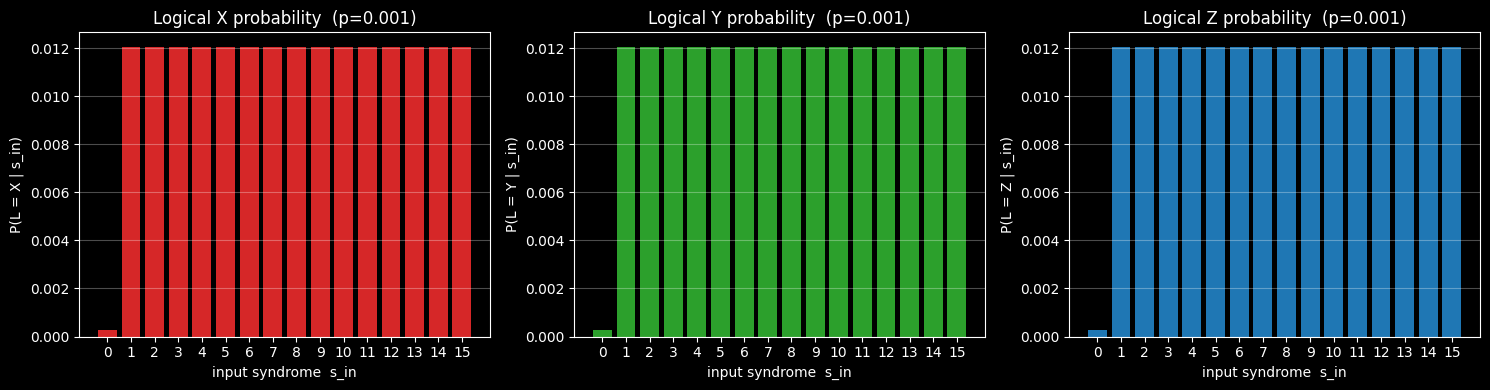

In [7]:

# ============================================================
#  Section B (cont.): 2-Pauli error enumeration — X exRec
# ============================================================
# Two of 15 locations non-identity. Paths/s_in: C(15,2)*9 = 945.
# Probability per path: p^2 * (1-p)^13
# ============================================================

from itertools import combinations
import matplotlib.pyplot as plt

M2_counts = np.zeros((16, 64), dtype=int)

def place_pauli(arrays, loc_idx, xb, zb):
    pos = loc_idx // 5
    q   = loc_idx % 5
    arrays[pos][0][q] ^= xb
    arrays[pos][1][q] ^= zb

for s_in in range(16):
    Ux_in, Uz_in = CORRECTIONS[s_in]
    for loc1, loc2 in combinations(range(15), 2):
        for xb1, zb1 in NON_ID:
            for xb2, zb2 in NON_ID:
                xP4 = np.zeros(5, dtype=int); zP4 = np.zeros(5, dtype=int)
                xP5 = np.zeros(5, dtype=int); zP5 = np.zeros(5, dtype=int)
                xP6 = np.zeros(5, dtype=int); zP6 = np.zeros(5, dtype=int)
                arrays = [(xP4, zP4), (xP5, zP5), (xP6, zP6)]
                place_pauli(arrays, loc1, xb1, zb1)
                place_pauli(arrays, loc2, xb2, zb2)

                xE, zE = pauli_mul(Ux_in, Uz_in, xP4, zP4)
                xE, zE = pauli_mul(xE, zE, xP5, zP5)
                xE, zE = pauli_mul(xE, zE, xP6, zP6)

                s_out = compute_syndrome(xE, zE)
                Qx, Qz = CORRECTIONS[s_out]
                xRes, zRes = pauli_mul(Qx, Qz, xE, zE)
                L_X, _ = logical_class(xRes, zRes)

                M2_counts[s_in, L_X * 16 + s_out] += 1

print(f"2-Pauli row sums (expect 945): {M2_counts.sum(axis=1).tolist()}")

# Total prob (order ≤ 2), marginalize over s_out
p_val = 1e-3
w1 = p_val * (1 - p_val)**14
w2 = p_val**2 * (1 - p_val)**13
M_total = M_counts * w1 + M2_counts * w2

P_marginal = np.zeros((16, 4))
for s_in in range(16):
    for L in range(4):
        P_marginal[s_in, L] = M_total[s_in, L*16:(L+1)*16].sum()

print()
print(f"P(L | s_in)  at p = {p_val}")
print(f"{'s_in':>4}  {'P(I)':>12}  {'P(X)':>12}  {'P(Y)':>12}  {'P(Z)':>12}")
for s_in in range(16):
    print(f"{s_in:4d}  " + "  ".join(f"{P_marginal[s_in, L]:12.4e}" for L in range(4)))

# Plot P(L=X), P(L=Y), P(L=Z) vs input syndrome
s_in_axis = np.arange(16)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['X', 'Y', 'Z']
colors = ['tab:red', 'tab:green', 'tab:blue']
for i, (lbl, color) in enumerate(zip(labels, colors)):
    L_idx = i + 1
    axes[i].bar(s_in_axis, P_marginal[:, L_idx], color=color)
    axes[i].set_xlabel('input syndrome  s_in')
    axes[i].set_ylabel(f'P(L = {lbl} | s_in)')
    axes[i].set_title(f'Logical {lbl} probability  (p={p_val})')
    axes[i].set_xticks(s_in_axis)
    axes[i].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
